# 6.32 - CertCF Alpha Ablation Across Datasets

Dedicated notebook to reproduce the epsilon-certification violin plot and retained-volume plot across all tabular datasets.

Important invariant: CertCF atlases are built using **model-predicted labels**, not dataset labels.


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import pickle
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from certcf import NearestOppositeClassClearanceStrategy
from counterfactuals.methods.certcf import CertCF
from counterfactuals.datasets.loaders import (
    AdultDataset,
    CompasDataset,
    GermanCreditDataset,
    GiveMeSomeCreditDataset,
    HELOCDataset,
    LendingClubDataset,
    WisconsinBreastCancerDataset,
)
from scripts.benchmark import _build_torch_model_from_checkpoint

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)



## Configuration

The default cap keeps the all-dataset run manageable. Set `MAX_POLYTOPES_PER_CLASS = None` only if you really want the full train support.


In [2]:
DATASET_CONFIGS = {
    'wisconsin_breast_cancer': {
        'loader': WisconsinBreastCancerDataset,
        'checkpoint': ROOT / 'checkpoints/wisconsin_breast_cancer_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'adult': {
        'loader': AdultDataset,
        'checkpoint': ROOT / 'checkpoints/adult_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'compas': {
        'loader': CompasDataset,
        'checkpoint': ROOT / 'checkpoints/compas_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'german_credit': {
        'loader': GermanCreditDataset,
        'checkpoint': ROOT / 'checkpoints/german_credit_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'heloc': {
        'loader': HELOCDataset,
        'checkpoint': ROOT / 'checkpoints/heloc_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'give_me_some_credit': {
        'loader': GiveMeSomeCreditDataset,
        'checkpoint': ROOT / 'checkpoints/give_me_some_credit_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
    'lending_club': {
        'loader': LendingClubDataset,
        'checkpoint': ROOT / 'checkpoints/lending_club_classifier/best.ckpt',
        'hidden_dims': [64, 32],
    },
}

DATASETS_TO_RUN = list(DATASET_CONFIGS)
ALPHAS = [0.01] + [round(a, 2) for a in np.arange(0.05, 1.00, 0.05)] + [0.99]

N_VOLUME_SAMPLES = 20_480
CLASSIFICATION_MARGIN = 1.0e-4
DEVICE = 'auto'
RANDOM_SEED = 42
ATLAS_LABEL_SOURCE = 'model_prediction'

# 100 per predicted class gives 200 polytopes per binary dataset.
MAX_POLYTOPES_PER_CLASS = 100

REBUILD_POLYTOPES = False
RECOMPUTE_VOLUMES = False

POLYTOPE_CACHE_DIR = ROOT / 'results/certcf_alpha_ablation_polytopes'
VOLUME_CACHE_DIR = ROOT / 'results/certcf_alpha_ablation_volumes'
POLYTOPE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
VOLUME_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print({
    'datasets': DATASETS_TO_RUN,
    'alphas': ALPHAS,
    'n_volume_samples': N_VOLUME_SAMPLES,
    'max_polytopes_per_class': MAX_POLYTOPES_PER_CLASS,
    'atlas_label_source': ATLAS_LABEL_SOURCE,
})



{'datasets': ['wisconsin_breast_cancer', 'adult', 'compas', 'german_credit', 'heloc', 'give_me_some_credit', 'lending_club'], 'alphas': [0.01, np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), 0.99], 'n_volume_samples': 20480, 'max_polytopes_per_class': 100, 'atlas_label_source': 'model_prediction'}


## Dataset And Model Helpers


In [3]:
def load_dataset_and_model(dataset_name: str):
    cfg = DATASET_CONFIGS[dataset_name]
    loader = cfg['loader'](data_dir=str(ROOT / 'data'), seed=RANDOM_SEED)
    loader.load()
    x_train, y_train = loader.get_train()
    x_test, y_test = loader.get_test()
    spec = loader.spec

    model = _build_torch_model_from_checkpoint(
        checkpoint=str(cfg['checkpoint']),
        device=DEVICE,
        dataset_module=dataset_name,
        hidden_dims=cfg['hidden_dims'],
        dropout=0.2,
    )
    y_train_atlas = model.predict(x_train).astype(np.int64)
    label_agreement = float(np.mean(y_train_atlas == y_train))

    dataset_info = {
        'dataset': dataset_name,
        'encoded_dim': int(x_train.shape[1]),
        'n_train': int(len(x_train)),
        'n_test': int(len(x_test)),
        'dataset_label_counts': dict(zip(*np.unique(y_train, return_counts=True))),
        'model_prediction_counts': dict(zip(*np.unique(y_train_atlas, return_counts=True))),
        'train_label_agreement_dataset_vs_model': label_agreement,
        'atlas_label_source': ATLAS_LABEL_SOURCE,
        'n_ohe_blocks': len(spec.categorical_slices),
    }
    return loader, spec, model, x_train, y_train, y_train_atlas, dataset_info


def dataset_feature_table(spec) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'feature': name,
            'type': feature_type,
            'encoded_slice': f'{start}:{end}',
            'encoded_width': int(end - start),
        }
        for name, feature_type, (start, end) in zip(spec.feature_names, spec.input_types, spec.feature_slices)
    ])



## Volume Estimation Helpers


In [4]:
def sample_l1_ball(center: np.ndarray, eps: float, n: int, rng: np.random.Generator) -> np.ndarray:
    center = np.asarray(center, dtype=np.float64).reshape(-1)
    d = center.size
    exponential = rng.exponential(scale=1.0, size=(int(n), d + 1))
    proportions = exponential / exponential.sum(axis=1, keepdims=True)
    magnitudes = float(eps) * proportions[:, :d]
    signs = rng.choice(np.array([-1.0, 1.0]), size=(int(n), d))
    return center[None, :] + signs * magnitudes


def log_l1_ball_volume(d: int, eps: float) -> float:
    if eps <= 0:
        return -np.inf
    return d * math.log(2.0) - math.lgamma(d + 1.0) + d * math.log(float(eps))


def log_removed_volume_from_fraction(log_ball_volume: float, retained_fraction: float) -> float:
    if not np.isfinite(log_ball_volume):
        return -np.inf
    retained_fraction = float(np.clip(retained_fraction, 0.0, 1.0))
    removed_fraction = 1.0 - retained_fraction
    return log_ball_volume + math.log(removed_fraction) if removed_fraction > 0 else -np.inf


def estimate_affine_region_fraction(A: np.ndarray, b: np.ndarray, samples: np.ndarray, margin: float = 0.0) -> float:
    margins = samples @ np.asarray(A, dtype=np.float64).T + np.asarray(b, dtype=np.float64)[None, :]
    return float(np.mean(np.all(margins >= float(margin), axis=1)))


def extract_atlas_approximations(
    atlas,
    dataset_name: str,
    alpha: float,
    margin: float = CLASSIFICATION_MARGIN,
) -> list[dict]:
    records = []
    for label in atlas.class_labels:
        bd = atlas.bounds[int(label)]
        for idx in range(len(bd['X'])):
            records.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'class_label': int(label),
                'polytope_idx': int(idx),
                'center': np.asarray(bd['X'][idx], dtype=np.float64).copy(),
                'eps': float(bd['eps'][idx]),
                'under_A': np.asarray(bd['lA'][idx], dtype=np.float64).copy(),
                'under_b': np.asarray(bd['lbias'][idx], dtype=np.float64).copy() - float(margin),
                'over_A': np.asarray(bd['uA'][idx], dtype=np.float64).copy(),
                'over_b': np.asarray(bd['ubias'][idx], dtype=np.float64).copy() - float(margin),
                'constraint_convention': 'A @ x + b >= 0',
                'trust_region': '||x - center||_1 <= eps',
            })
    return records


def estimate_approximation_records_volumes(
    records: list[dict],
    alpha: float,
    n_samples: int = N_VOLUME_SAMPLES,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(int(seed) + int(round(float(alpha) * 10_000)))

    for rec in records:
        center = np.asarray(rec['center'], dtype=np.float64).reshape(-1)
        eps_i = float(rec['eps'])
        samples = sample_l1_ball(center, eps_i, n_samples, rng)

        under_fraction = estimate_affine_region_fraction(rec['under_A'], rec['under_b'], samples, margin=0.0)
        over_fraction = estimate_affine_region_fraction(rec['over_A'], rec['over_b'], samples, margin=0.0)
        log_ball = log_l1_ball_volume(center.size, eps_i)
        ball_volume = math.exp(log_ball) if np.isfinite(log_ball) else 0.0
        under_removed_fraction = 1.0 - float(np.clip(under_fraction, 0.0, 1.0))
        over_removed_fraction = 1.0 - float(np.clip(over_fraction, 0.0, 1.0))

        rows.append({
            'dataset': rec['dataset'],
            'alpha': float(alpha),
            'class_label': int(rec['class_label']),
            'polytope_idx': int(rec['polytope_idx']),
            'eps': eps_i,
            'dimension': int(center.size),
            'n_samples': int(n_samples),
            'under_fraction': under_fraction,
            'over_fraction': over_fraction,
            'under_removed_fraction': under_removed_fraction,
            'over_removed_fraction': over_removed_fraction,
            'log_ball_volume': log_ball,
            'log_under_volume': log_ball + math.log(under_fraction) if under_fraction > 0 else -np.inf,
            'log_over_volume': log_ball + math.log(over_fraction) if over_fraction > 0 else -np.inf,
            'log_under_removed_volume': log_removed_volume_from_fraction(log_ball, under_fraction),
            'log_over_removed_volume': log_removed_volume_from_fraction(log_ball, over_fraction),
            'ball_volume': ball_volume,
            'under_volume': ball_volume * under_fraction,
            'over_volume': ball_volume * over_fraction,
            'under_removed_volume': ball_volume * under_removed_fraction,
            'over_removed_volume': ball_volume * over_removed_fraction,
        })
    return pd.DataFrame(rows)


def estimate_cached_approximation_volumes(
    approximations_by_alpha: dict[float, list[dict]],
    n_samples: int = N_VOLUME_SAMPLES,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    frames = []
    for alpha in sorted(approximations_by_alpha):
        print(f'estimating volumes for alpha={alpha} with n_samples={n_samples}')
        frames.append(estimate_approximation_records_volumes(
            approximations_by_alpha[alpha], alpha=float(alpha), n_samples=n_samples, seed=seed,
        ))
    return pd.concat(frames, ignore_index=True)



## Build / Load Cached Polytopes


In [5]:
def polytope_cache_path(dataset_name: str) -> Path:
    cap = 'full' if MAX_POLYTOPES_PER_CLASS is None else f'k{MAX_POLYTOPES_PER_CLASS}'
    return POLYTOPE_CACHE_DIR / f'{dataset_name}_model_predictions_{cap}.pkl'


def volume_cache_path(dataset_name: str) -> Path:
    cap = 'full' if MAX_POLYTOPES_PER_CLASS is None else f'k{MAX_POLYTOPES_PER_CLASS}'
    return VOLUME_CACHE_DIR / f'{dataset_name}_model_predictions_{cap}_samples{N_VOLUME_SAMPLES}.parquet'


def build_or_load_polytopes_for_dataset(dataset_name: str) -> dict:
    cache_path = polytope_cache_path(dataset_name)
    if cache_path.exists() and not REBUILD_POLYTOPES:
        with cache_path.open('rb') as f:
            cache = pickle.load(f)
        if cache.get('atlas_label_source') != ATLAS_LABEL_SOURCE:
            raise ValueError(f'{dataset_name}: cache label source mismatch: {cache.get("atlas_label_source")!r}')
        print(f'[{dataset_name}] loaded polytopes from {cache_path}')
        return cache

    loader, spec, model, x_train, y_train, y_train_atlas, dataset_info = load_dataset_and_model(dataset_name)
    print(f'[{dataset_name}] building polytopes with model-predicted labels')
    print(dataset_info)

    atlas_build_summaries = []
    approximations_by_alpha = {}

    for alpha in ALPHAS:
        print(f'[{dataset_name}] alpha={alpha}')
        method = CertCF(
            model=model,
            norm=1,
            distance_norm=1,
            lirpa_method='backward',
            eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(alpha)),
            batch_size=128,
            ohe_slices=list(spec.categorical_slices),
            default_query_method='nearest_anchor',
            query_k_candidates=5,
            k_per_class=MAX_POLYTOPES_PER_CLASS,
            subsample_method='random',
            classification_margin=CLASSIFICATION_MARGIN,
            random_seed=RANDOM_SEED,
        )

        t0 = time.perf_counter()
        method.fit(x_train=x_train, y_train=y_train_atlas)
        build_time_s = time.perf_counter() - t0
        atlas = method.atlas

        atlas_build_summaries.append({
            'dataset': dataset_name,
            'alpha': float(alpha),
            'build_time_s': build_time_s,
            'n_polytopes': int(sum(len(atlas.bounds[label]['X']) for label in atlas.class_labels)),
            'eps_min': float(min(np.min(atlas.bounds[label]['eps']) for label in atlas.class_labels)),
            'eps_max': float(max(np.max(atlas.bounds[label]['eps']) for label in atlas.class_labels)),
        })
        approximations_by_alpha[float(alpha)] = extract_atlas_approximations(
            atlas, dataset_name=dataset_name, alpha=float(alpha)
        )
        display(pd.DataFrame(atlas_build_summaries).tail(1).round(4))

    cache = {
        'dataset': dataset_name,
        'alphas': ALPHAS,
        'classification_margin': CLASSIFICATION_MARGIN,
        'max_polytopes_per_class': MAX_POLYTOPES_PER_CLASS,
        'atlas_label_source': ATLAS_LABEL_SOURCE,
        'dataset_info': dataset_info,
        'feature_table': dataset_feature_table(spec),
        'approximations_by_alpha': approximations_by_alpha,
        'atlas_build_summary': pd.DataFrame(atlas_build_summaries),
    }
    with cache_path.open('wb') as f:
        pickle.dump(cache, f)
    print(f'[{dataset_name}] saved polytopes to {cache_path}')
    return cache


def build_or_load_volumes_for_dataset(dataset_name: str, approximations_by_alpha: dict[float, list[dict]]) -> pd.DataFrame:
    cache_path = volume_cache_path(dataset_name)
    if cache_path.exists() and not RECOMPUTE_VOLUMES:
        print(f'[{dataset_name}] loaded volumes from {cache_path}')
        return pd.read_parquet(cache_path)

    volume_df = estimate_cached_approximation_volumes(
        approximations_by_alpha,
        n_samples=N_VOLUME_SAMPLES,
        seed=RANDOM_SEED,
    )
    volume_df.to_parquet(cache_path, index=False)
    print(f'[{dataset_name}] saved volumes to {cache_path}')
    return volume_df



## Run Selected Datasets

This cell builds/loads polytopes and computes/loads volume estimates for every selected dataset.


In [6]:
DATASET_CACHES = {}
VOLUME_FRAMES = []
RUN_SUMMARIES = []
BUILD_SUMMARY_FRAMES = []

for dataset_name in DATASETS_TO_RUN:
    cache = build_or_load_polytopes_for_dataset(dataset_name)
    DATASET_CACHES[dataset_name] = cache
    BUILD_SUMMARY_FRAMES.append(cache['atlas_build_summary'])

    volume_df = build_or_load_volumes_for_dataset(dataset_name, cache['approximations_by_alpha'])
    VOLUME_FRAMES.append(volume_df)

    info = dict(cache['dataset_info'])
    info['volume_rows'] = int(len(volume_df))
    info['n_samples'] = int(volume_df['n_samples'].iloc[0]) if len(volume_df) else 0
    RUN_SUMMARIES.append(info)

ALL_VOLUME_DF = pd.concat(VOLUME_FRAMES, ignore_index=True)
ALL_BUILD_SUMMARY_DF = pd.concat(BUILD_SUMMARY_FRAMES, ignore_index=True)
DATASET_RUN_SUMMARY_DF = pd.DataFrame(RUN_SUMMARIES)

display(DATASET_RUN_SUMMARY_DF)
display(ALL_BUILD_SUMMARY_DF.groupby('dataset').agg(
    n_alpha=('alpha', 'nunique'),
    n_polytopes_min=('n_polytopes', 'min'),
    n_polytopes_max=('n_polytopes', 'max'),
    eps_min=('eps_min', 'min'),
    eps_max=('eps_max', 'max'),
).round(4))



[INFO] model device normalized: 'auto' -> 'cuda'
[wisconsin_breast_cancer] building polytopes with model-predicted labels
{'dataset': 'wisconsin_breast_cancer', 'encoded_dim': 30, 'n_train': 457, 'n_test': 56, 'dataset_label_counts': {np.int64(0): np.int64(283), np.int64(1): np.int64(174)}, 'model_prediction_counts': {np.int64(0): np.int64(283), np.int64(1): np.int64(174)}, 'train_label_agreement_dataset_vs_model': 0.9912472647702407, 'atlas_label_source': 'model_prediction', 'n_ohe_blocks': 0}
[wisconsin_breast_cancer] alpha=0.01
Building certified atlas (eps in [0.07186, 0.7419] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:03<00:00,  1.61s/it]

  Building BVH spatial indices...
    Class 0: 100 polytopes, tree depth 8
    Class 1: 100 polytopes, tree depth 8
Done! Total: 200 polytopes across 2 classes


,dataset,alpha,build_time_s,n_polytopes,eps_min,eps_max
0,wisconsin_breast_cancer,0.01,3.2285,200,0.0719,0.7419


[wisconsin_breast_cancer] alpha=0.05
Building certified atlas (eps in [0.3593, 3.709] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


...

  Building BVH spatial indices...
    Class 0: 100 polytopes, tree depth 8
    Class 1: 100 polytopes, tree depth 8
Done! Total: 200 polytopes across 2 classes


,dataset,alpha,build_time_s,n_polytopes,eps_min,eps_max
20,lending_club,0.99,2.948,200,1.5794,13.6982


[lending_club] saved polytopes to /home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/certcf_alpha_ablation_polytopes/lending_club_model_predictions_k100.pkl
estimating volumes for alpha=0.01 with n_samples=20480
estimating volumes for alpha=0.05 with n_samples=20480
estimating volumes for alpha=0.1 with n_samples=20480
estimating volumes for alpha=0.15 with n_samples=20480
estimating volumes for alpha=0.2 with n_samples=20480
estimating volumes for alpha=0.25 with n_samples=20480
estimating volumes for alpha=0.3 with n_samples=20480
estimating volumes for alpha=0.35 with n_samples=20480
estimating volumes for alpha=0.4 with n_samples=20480
estimating volumes for alpha=0.45 with n_samples=20480
estimating volumes for alpha=0.5 with n_samples=20480
estimating volumes for alpha=0.55 with n_samples=20480
estimating volumes for alpha=0.6 with n_samples=20480
estimating volumes for alpha=0.65 with n_samples=20480
estimating volumes for alpha=0.7 with n_samples=20480

,dataset,encoded_dim,n_train,n_test,dataset_label_counts,model_prediction_counts,train_label_agreement_dataset_vs_model,atlas_label_source,n_ohe_blocks,volume_rows,n_samples
0,wisconsin_breast_cancer,30,457,56,"{0: 283, 1: 174}","{0: 283, 1: 174}",0.991247,model_prediction,0,4200,20480
1,adult,104,36178,4522,"{0: 27224, 1: 8954}","{0: 22850, 1: 13328}",0.822323,model_prediction,8,4200,20480
2,compas,14,4938,617,"{0: 2703, 1: 2235}","{0: 2849, 1: 2089}",0.696233,model_prediction,3,4200,20480
3,german_credit,61,800,100,"{0: 554, 1: 246}","{0: 492, 1: 308}",0.840000,model_prediction,13,4200,20480
4,heloc,23,8369,1045,"{0: 3989, 1: 4380}","{0: 3789, 1: 4580}",0.740949,model_prediction,0,4200,20480
5,give_me_some_credit,10,120000,15000,"{0: 112036, 1: 7964}","{0: 96361, 1: 23639}",0.827308,model_prediction,0,4200,20480
6,lending_club,25,30823,3852,"{0: 26301, 1: 4522}","{0: 17206, 1: 13617}",0.617266,model_prediction,4,4200,20480


,n_alpha,n_polytopes_min,n_polytopes_max,eps_min,eps_max
dataset,,,,,
adult,21,200,200,0.0059,12.6905
compas,21,200,200,0.0009,33.5222
german_credit,21,200,200,0.0590,18.5690
give_me_some_credit,21,200,200,0.0036,7.4173
heloc,21,200,200,0.0442,50.3680
lending_club,21,200,200,0.0160,13.6982
wisconsin_breast_cancer,21,200,200,0.0719,73.4461


## Plot Helpers


In [7]:
def build_epsilon_certification_df(
    volume_df: pd.DataFrame,
    approximation: str = 'under',
    certified_threshold: float = 0.0,
) -> pd.DataFrame:
    fraction_col = f'{approximation}_fraction'
    if fraction_col not in volume_df.columns:
        raise KeyError(f'Missing column {fraction_col!r}.')
    out = volume_df[[
        'dataset', 'alpha', 'class_label', 'polytope_idx', 'eps', fraction_col,
    ]].rename(columns={fraction_col: 'retained_fraction'}).copy()
    out['certified'] = out['retained_fraction'].gt(float(certified_threshold))
    out['status'] = np.where(out['certified'], 'certified', 'not certified')
    out['approximation'] = approximation
    out['certified_threshold'] = float(certified_threshold)
    return out.sort_values(['dataset', 'alpha', 'certified', 'eps'], ignore_index=True)


def plot_epsilon_violin_by_alpha_certification(
    volume_df: pd.DataFrame,
    dataset_name: str,
    alphas: list[float] | None = None,
    approximation: str = 'under',
    certified_threshold: float = 0.0,
):
    if alphas is None:
        alphas = ALPHAS
    dataset_df = volume_df[volume_df['dataset'].eq(dataset_name)].copy()
    plot_df = build_epsilon_certification_df(
        dataset_df,
        approximation=approximation,
        certified_threshold=certified_threshold,
    )
    alpha_values = [float(a) for a in alphas]
    plot_df = plot_df[plot_df['alpha'].isin(alpha_values)].copy()
    if plot_df.empty:
        raise ValueError(f'No rows available for {dataset_name}.')

    status_order = ['certified', 'not certified']
    colors = {'certified': '#087F5B', 'not certified': '#C92A2A'}
    offsets = {'certified': -0.18, 'not certified': 0.18}

    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    legend_handles = []
    for status in status_order:
        data = []
        positions = []
        for alpha_idx, alpha in enumerate(alpha_values):
            values = plot_df.loc[
                np.isclose(plot_df['alpha'].astype(float), alpha) & plot_df['status'].eq(status),
                'eps',
            ].to_numpy(dtype=float)
            values = values[np.isfinite(values) & (values > 0.0)]
            if len(values) == 0:
                continue
            data.append(values)
            positions.append(alpha_idx + offsets[status])
        if not data:
            continue

        violins = ax.violinplot(
            data,
            positions=positions,
            widths=0.30,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
        for body in violins['bodies']:
            body.set_facecolor(colors[status])
            body.set_edgecolor(colors[status])
            body.set_alpha(0.35)
            body.set_linewidth(0.8)
        violins['cmedians'].set_color(colors[status])
        violins['cmedians'].set_linewidth(1.5)
        legend_handles.append(plt.Line2D([0], [0], color=colors[status], linewidth=6, alpha=0.35, label=status))

    ax.set_title(
        f'{dataset_name}: distribuzione dei raggi epsilon dei polytopes\n'
        'separati tra certificati e non certificati'
    )
    ax.set_xlabel('alpha')
    ax.set_ylabel('epsilon (log scale)')
    ax.set_yscale('log')
    ax.set_xticks(range(len(alpha_values)))
    ax.set_xticklabels([f'{alpha:g}' for alpha in alpha_values], rotation=45, ha='right')
    ax.grid(True, axis='y', which='major', alpha=0.25)
    ax.grid(True, axis='y', which='minor', alpha=0.10)
    ax.legend(handles=legend_handles, frameon=False, loc='best')
    fig.tight_layout()
    return fig, ax


def ensure_retained_fraction_long_df(volume_df: pd.DataFrame) -> pd.DataFrame:
    under = volume_df[[
        'dataset', 'alpha', 'class_label', 'polytope_idx', 'eps', 'dimension', 'n_samples',
        'under_fraction', 'log_under_volume',
    ]].rename(columns={'under_fraction': 'retained_fraction', 'log_under_volume': 'log_volume'})
    under['approximation'] = 'under'

    over = volume_df[[
        'dataset', 'alpha', 'class_label', 'polytope_idx', 'eps', 'dimension', 'n_samples',
        'over_fraction', 'log_over_volume',
    ]].rename(columns={'over_fraction': 'retained_fraction', 'log_over_volume': 'log_volume'})
    over['approximation'] = 'over'

    out = pd.concat([under, over], ignore_index=True)
    out['retained_fraction'] = out['retained_fraction'].clip(0.0, 1.0)
    out['log10_volume'] = out['log_volume'] / math.log(10.0)
    return out


def plot_retained_volume_by_alpha(
    volume_df: pd.DataFrame,
    dataset_name: str,
):
    plot_df = ensure_retained_fraction_long_df(volume_df)
    plot_df = plot_df[plot_df['dataset'].eq(dataset_name)].copy()
    positive = plot_df.loc[plot_df['retained_fraction'].gt(0.0), 'retained_fraction']
    floor = max(float(positive.min()) * 0.5, 1e-8) if len(positive) else 1e-8
    plot_df['retained_fraction_for_plot'] = plot_df['retained_fraction'].clip(lower=floor)

    colors = {'under': '#087F5B', 'over': '#C92A2A'}
    labels = {'under': 'under approximation', 'over': 'over approximation'}

    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    for approx in ['under', 'over']:
        side = plot_df[plot_df['approximation'].eq(approx)]
        stats = (
            side.groupby('alpha')['retained_fraction_for_plot']
            .agg(mean='mean', median='median')
            .reset_index()
            .sort_values('alpha')
        )
        x = stats['alpha'].to_numpy(dtype=float)
        mean = stats['mean'].to_numpy(dtype=float)
        median = stats['median'].to_numpy(dtype=float)
        ax.plot(x, median, color=colors[approx], marker='o', markersize=4, linewidth=2.0, label=f'{labels[approx]} median')
        ax.plot(x, mean, color=colors[approx], marker='s', markersize=3.5, linewidth=1.8, linestyle='--', label=f'{labels[approx]} mean')

    ax.set_title(
        f'{dataset_name}: frazione della palla L1 che rimane dopo i vincoli LiRPA\n'
        'valori alti indicano regioni certificate piu ampie'
    )
    ax.set_xlabel('alpha')
    ax.set_ylabel('retained volume fraction (log scale)')
    ax.set_yscale('log')
    ax.set_ylim(floor, 1.15)
    ax.set_xticks(sorted(plot_df['alpha'].unique()))
    ax.set_xticklabels([f'{alpha:g}' for alpha in sorted(plot_df['alpha'].unique())], rotation=45, ha='right')
    ax.grid(True, which='major', axis='both', alpha=0.25)
    ax.grid(True, which='minor', axis='y', alpha=0.10)
    ax.legend(frameon=False, loc='best')
    fig.tight_layout()
    return fig, ax



## Plots For Every Dataset


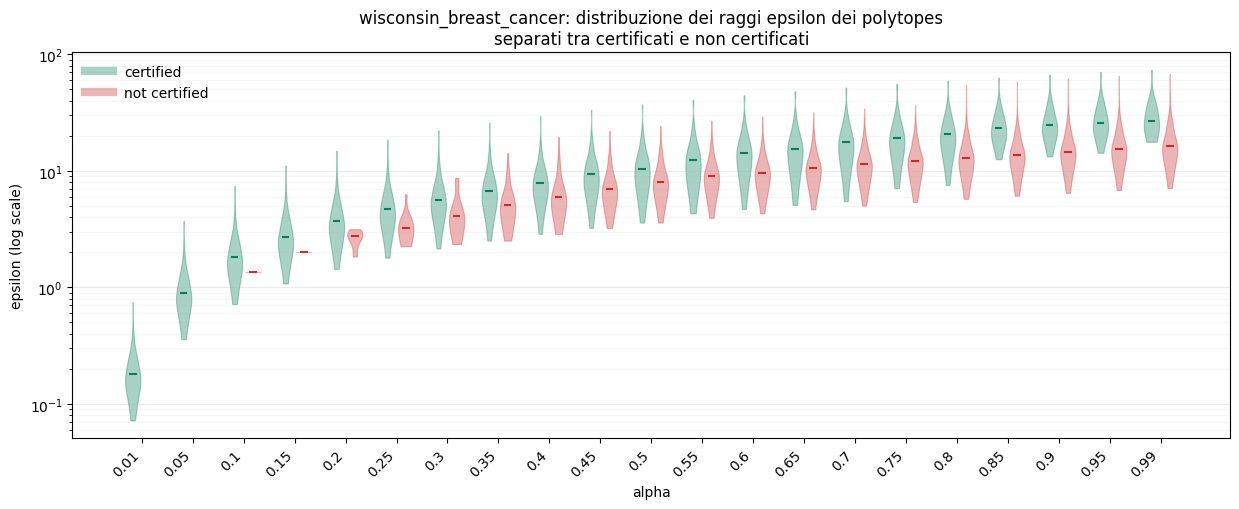

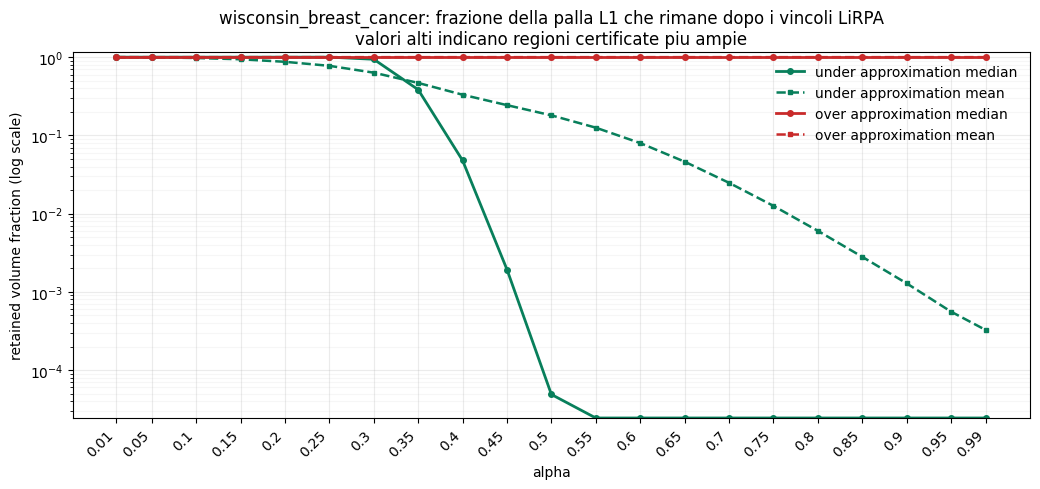

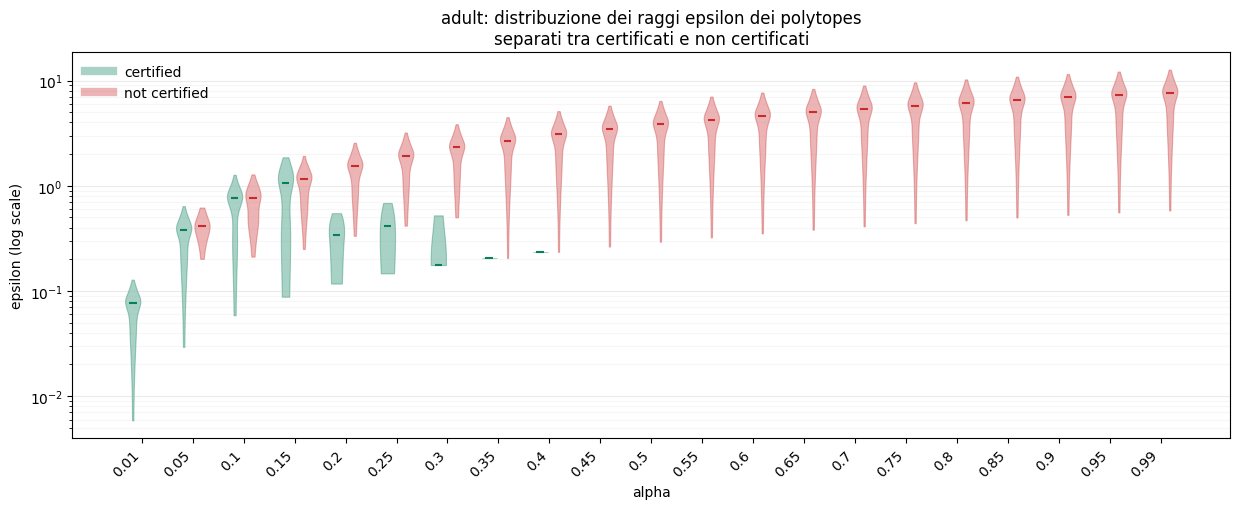

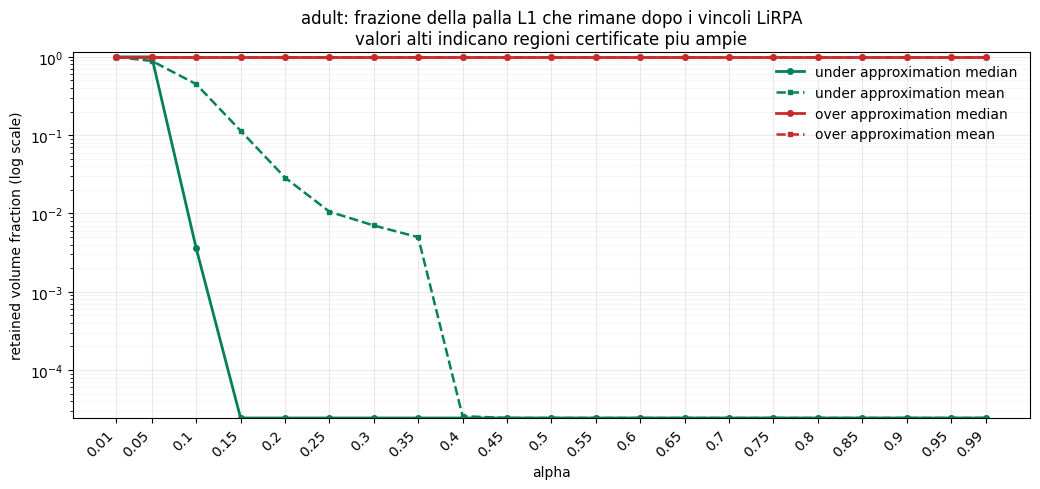

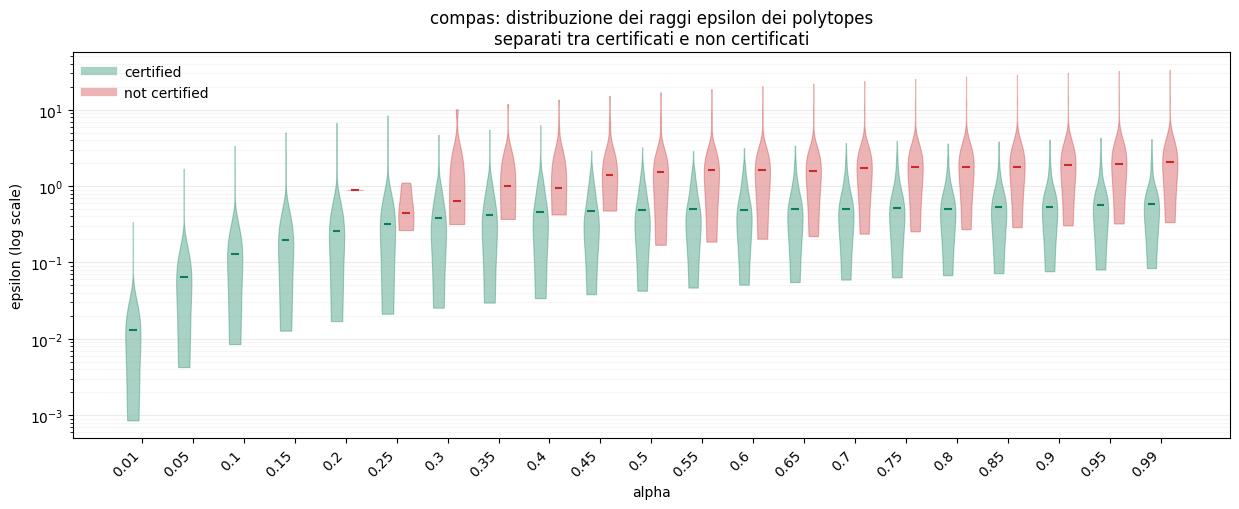

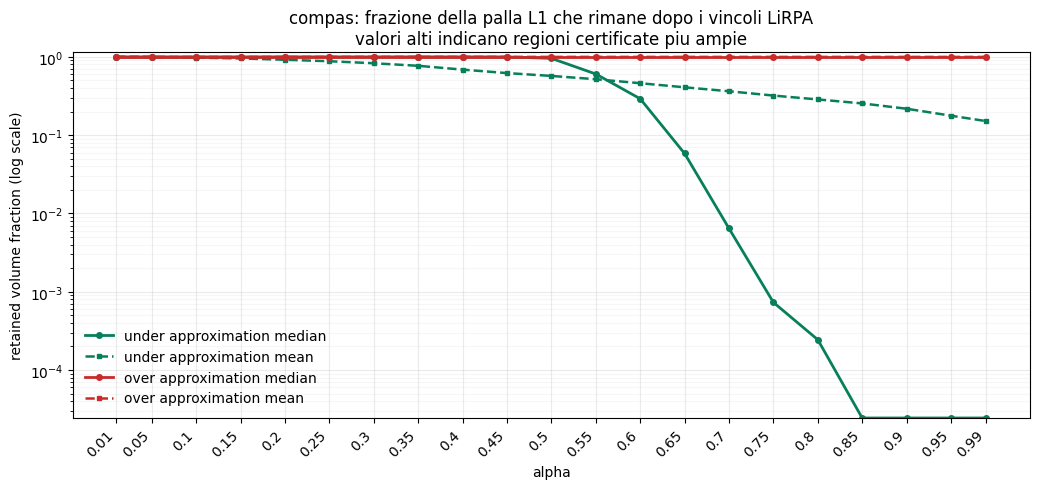

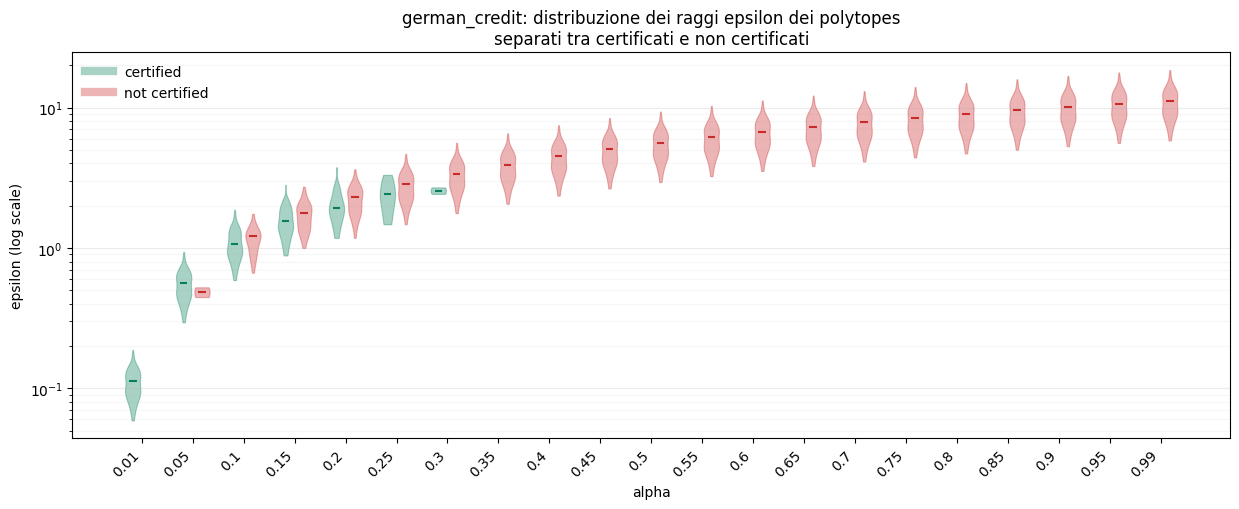

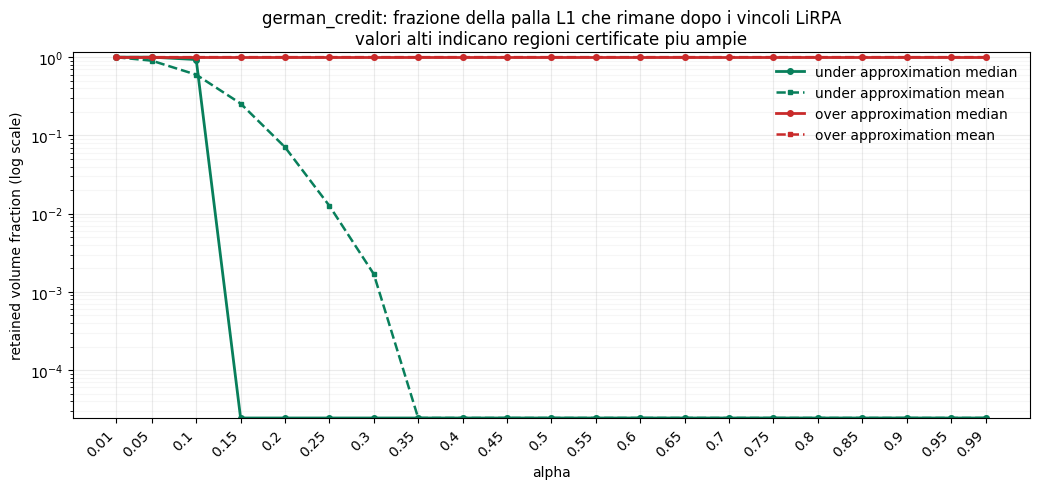

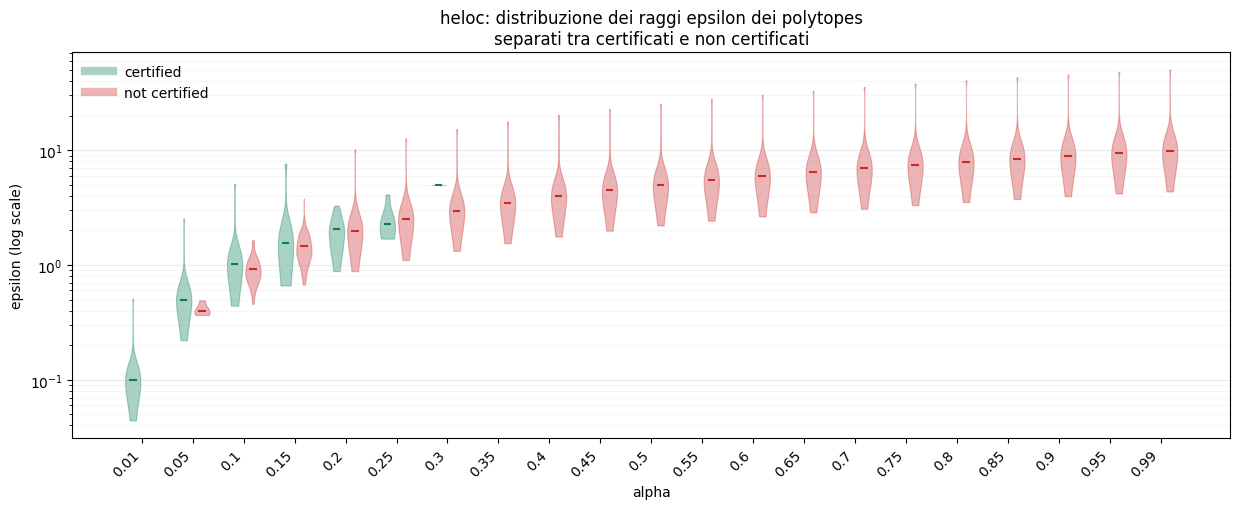

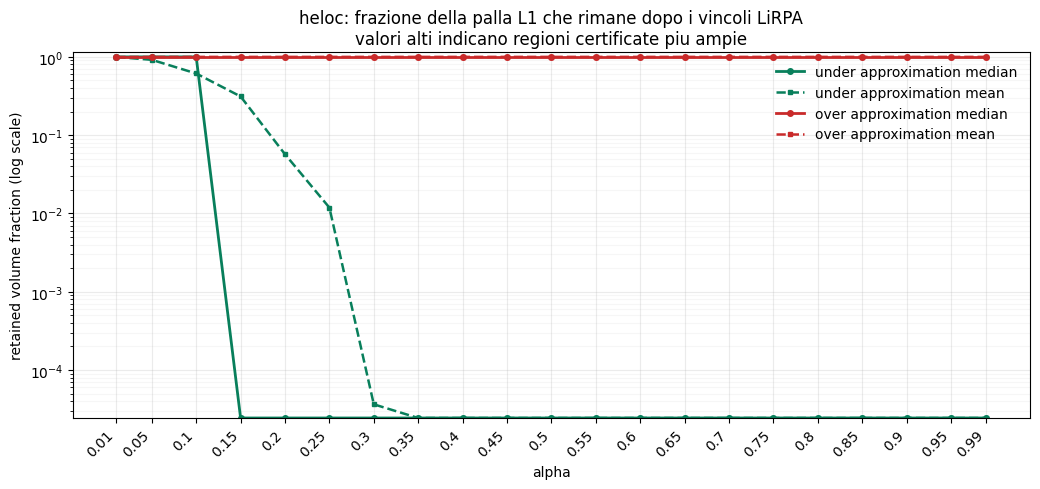

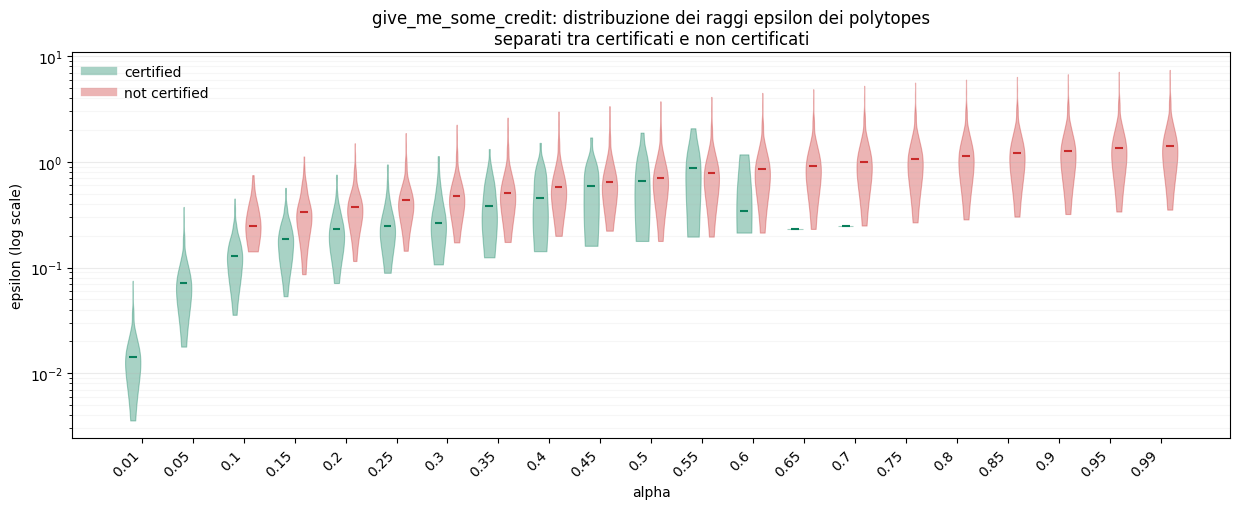

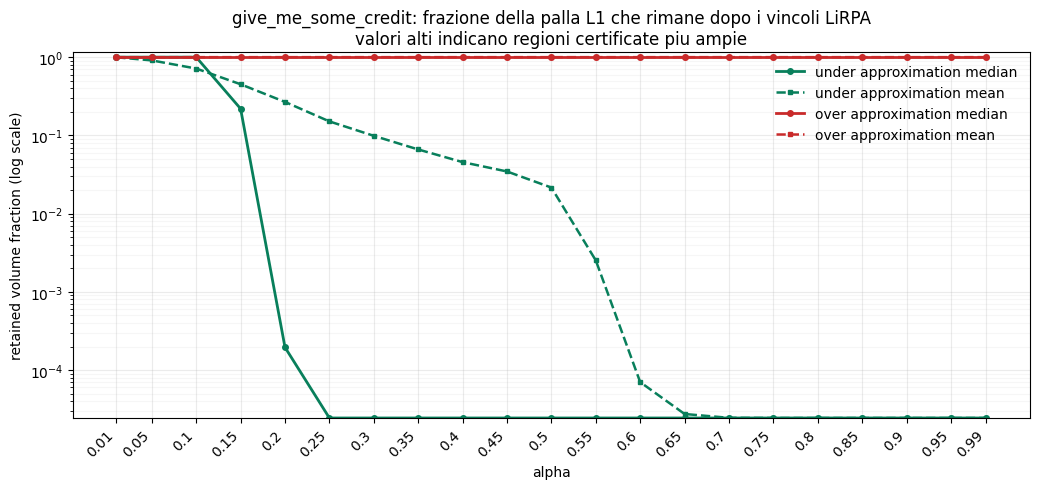

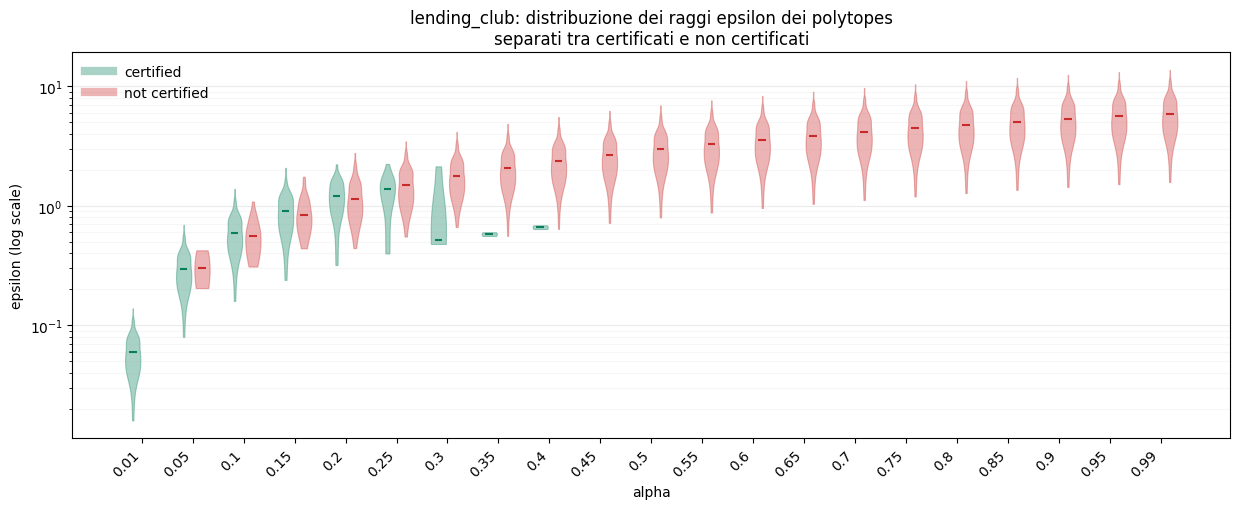

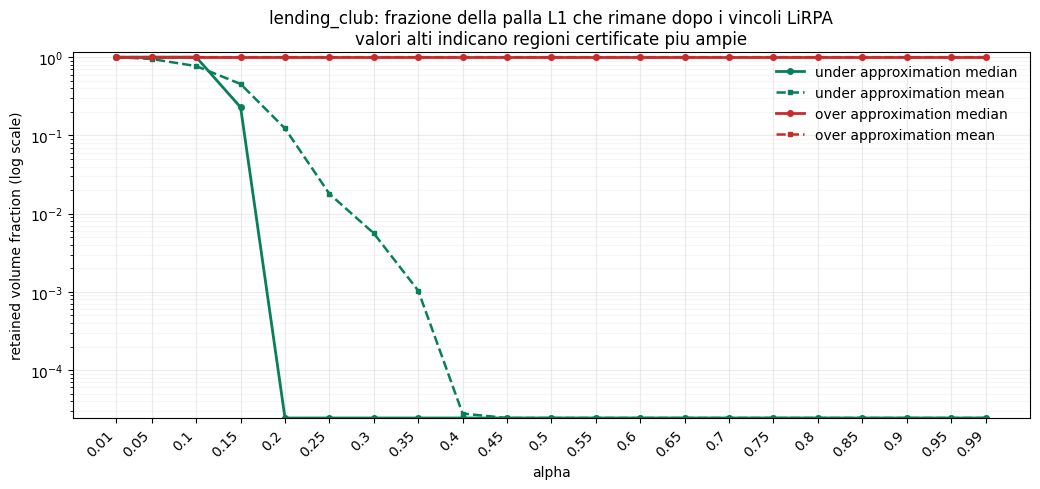

In [8]:
for dataset_name in DATASETS_TO_RUN:
    plot_epsilon_violin_by_alpha_certification(
        ALL_VOLUME_DF,
        dataset_name=dataset_name,
        alphas=ALPHAS,
        approximation='under',
        certified_threshold=0.0,
    )
    plt.show()

    plot_retained_volume_by_alpha(
        ALL_VOLUME_DF,
        dataset_name=dataset_name,
    )
    plt.show()



## Optional: Single Dataset Replot

Use this cell when you only want to redraw one dataset without rerunning the whole display loop.


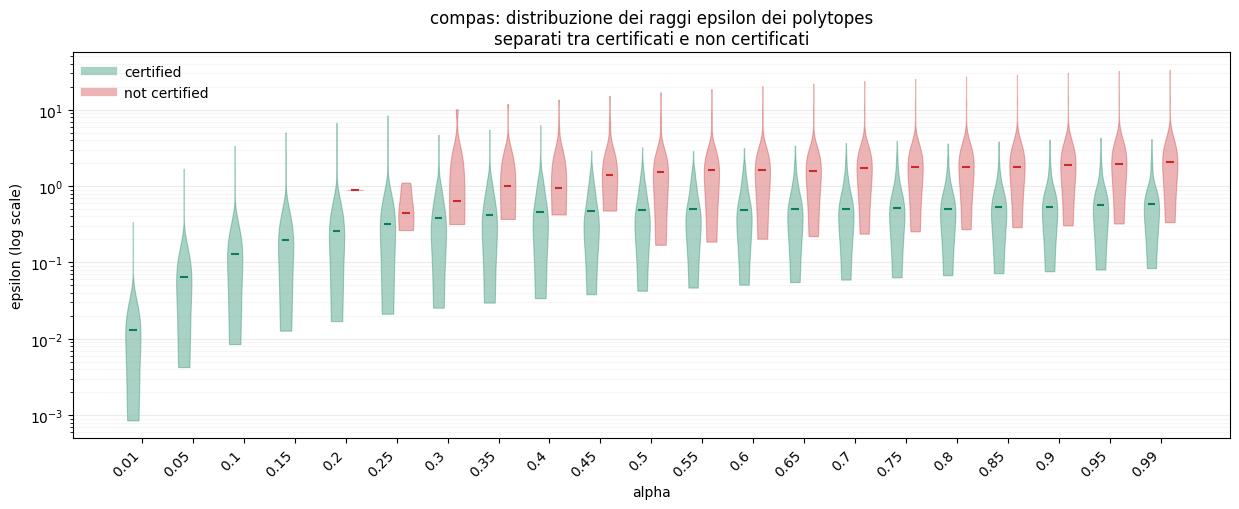

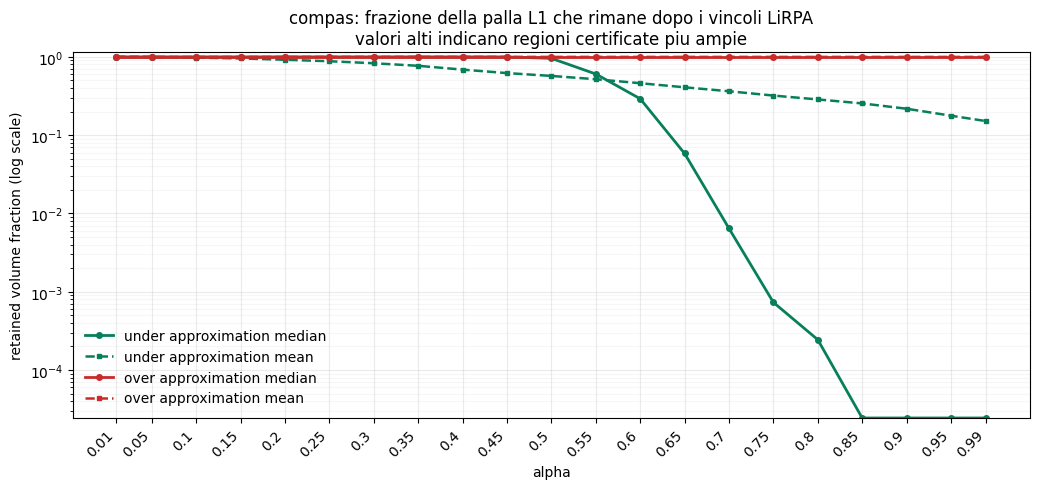

In [9]:
DATASET_TO_PLOT = 'compas'

plot_epsilon_violin_by_alpha_certification(
    ALL_VOLUME_DF,
    dataset_name=DATASET_TO_PLOT,
    alphas=ALPHAS,
    approximation='under',
    certified_threshold=0.0,
)
plt.show()

plot_retained_volume_by_alpha(
    ALL_VOLUME_DF,
    dataset_name=DATASET_TO_PLOT,
)
plt.show()

